# 05 Texture Generation

This notebook generates a texture set for Workflow 1 in Blender.

Rather than using generic materials, the textures are derived from the semantic labels
produced in Part 1. Emotion controls the visual style, while scene labels influence
pattern direction and composition.

The output is a set of texture images and a CSV mapping table for Blender.

## 1. Load parameter table

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFilter

PROJECT_DIR = Path.cwd().resolve().parents[1]  # notebooks/PART2 -> project root
PARAM_CSV = PROJECT_DIR / "data" / "processed" / "parameters" / "parameter_table.csv"
TEXTURE_DIR = PROJECT_DIR / "data" / "textures"
TEXTURE_DIR.mkdir(parents=True, exist_ok=True)

for folder in ["curious", "anxious", "dreamlike", "neutral"]:
    (TEXTURE_DIR / folder).mkdir(parents=True, exist_ok=True)

param_df = pd.read_csv(PARAM_CSV)
param_df.head()

,fragment_id,text_id,scene_label,emotion,scene_order_param,narrative_family,motion_intensity,image_id,height,complexity,...,fragment_family,audio_id,motion_amp,temporal_sharpness,duration_factor,motion_family,width,depth,roughness,anim_speed
0,fragment_0000,alice_ch02_c001,rabbit_hole,curious,0.000,2,0.083333,img_0000,5.706638,3.688531,...,3,audio_0000,0.164603,6.938920,0.019870,0,2.962033,2.844266,0.368853,2.387784
1,fragment_0001,alice_ch02_c002,rabbit_hole,curious,0.625,2,0.833333,img_0001,3.938032,1.024138,...,0,audio_0001,1.603978,0.441276,0.132905,3,3.312743,1.512069,0.102414,1.088255
2,fragment_0002,alice_ch02_c003,rabbit_hole,curious,1.250,2,0.666667,img_0002,5.569392,1.958124,...,1,audio_0002,1.396816,0.399610,0.230141,3,2.521727,1.979062,0.195812,1.079922
3,fragment_0003,alice_ch02_c004,dream_fall,curious,1.875,2,0.666667,img_0003,4.507636,2.305536,...,0,audio_0003,1.201737,2.685544,0.009985,3,2.748252,2.152768,0.230554,1.537109
4,fragment_0004,alice_ch02_c005,dream_fall,curious,2.500,2,0.666667,img_0004,2.388112,6.639730,...,2,audio_0004,0.521050,2.023362,0.007794,3,2.730426,4.319865,0.663973,1.404672


## 2. Generate procedural textures from semantic labels

In [2]:
texture_df = param_df[["fragment_id", "scene_label", "emotion"]].copy()
texture_df.head()

,fragment_id,scene_label,emotion
0,fragment_0000,rabbit_hole,curious
1,fragment_0001,rabbit_hole,curious
2,fragment_0002,rabbit_hole,curious
3,fragment_0003,dream_fall,curious
4,fragment_0004,dream_fall,curious


In [3]:
def hex_to_rgb(hex_color: str):
    hex_color = hex_color.lstrip("#")
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

PALETTES = {
    "curious": ["#d9e8ff", "#a9c8ff", "#6e9cf5"],
    "anxious": ["#ffd6d6", "#ff8a8a", "#d94c4c"],
    "dreamlike": ["#efe3ff", "#caa8ff", "#8f6de8"],
    "neutral": ["#eeeeee", "#cccccc", "#888888"],
}

def get_palette(emotion: str):
    return PALETTES.get(emotion, PALETTES["neutral"])

In [4]:
def make_gradient_texture(size, colors, vertical=True):
    w, h = size
    c1 = np.array(hex_to_rgb(colors[0]), dtype=np.float32)
    c2 = np.array(hex_to_rgb(colors[1]), dtype=np.float32)

    if vertical:
        t = np.linspace(0, 1, h)[:, None]
        arr = (1 - t) * c1 + t * c2
        arr = np.repeat(arr[:, None, :], w, axis=1)
    else:
        t = np.linspace(0, 1, w)[None, :]
        arr = (1 - t[..., None]) * c1 + t[..., None] * c2
        arr = np.repeat(arr, h, axis=0)

    return Image.fromarray(np.uint8(arr))


def add_dots(img, color="#ffffff", count=30, min_r=8, max_r=30, alpha=80):
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    rgb = hex_to_rgb(color)

    for _ in range(count):
        x = np.random.randint(0, img.size[0])
        y = np.random.randint(0, img.size[1])
        r = np.random.randint(min_r, max_r)
        draw.ellipse((x-r, y-r, x+r, y+r), fill=(*rgb, alpha))

    return Image.alpha_composite(img.convert("RGBA"), overlay).convert("RGB")


def add_stripes(img, color="#ffffff", spacing=20, width=6, vertical=True, alpha=60):
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    rgb = hex_to_rgb(color)

    if vertical:
        for x in range(0, img.size[0], spacing):
            draw.rectangle((x, 0, x+width, img.size[1]), fill=(*rgb, alpha))
    else:
        for y in range(0, img.size[1], spacing):
            draw.rectangle((0, y, img.size[0], y+width), fill=(*rgb, alpha))

    return Image.alpha_composite(img.convert("RGBA"), overlay).convert("RGB")


def add_noise(img, amount=25):
    arr = np.array(img).astype(np.int16)
    noise = np.random.randint(-amount, amount + 1, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def add_soft_blur(img, radius=2):
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

In [5]:
def build_texture(emotion: str, scene_label: str, size=(512, 512)):
    palette = get_palette(emotion)

    # base gradient direction from scene_label
    if scene_label == "rabbit_hole":
        img = make_gradient_texture(size, palette[:2], vertical=True)
        img = add_stripes(img, color=palette[2], spacing=28, width=10, vertical=True, alpha=40)

    elif scene_label == "corridor":
        img = make_gradient_texture(size, palette[:2], vertical=False)
        img = add_stripes(img, color=palette[2], spacing=22, width=8, vertical=False, alpha=45)

    elif scene_label == "dream_fall":
        img = make_gradient_texture(size, palette[:2], vertical=True)
        img = add_dots(img, color=palette[2], count=45, min_r=10, max_r=40, alpha=55)
        img = add_soft_blur(img, radius=1.8)

    elif scene_label == "nonsense":
        img = make_gradient_texture(size, palette[:2], vertical=False)
        img = add_noise(img, amount=35)
        img = add_stripes(img, color=palette[2], spacing=35, width=12, vertical=np.random.choice([True, False]), alpha=50)

    else:
        img = make_gradient_texture(size, palette[:2], vertical=True)
        img = add_dots(img, color=palette[2], count=20, min_r=8, max_r=20, alpha=40)

    # emotion-specific final style
    if emotion == "curious":
        img = add_dots(img, color="#ffffff", count=18, min_r=6, max_r=18, alpha=35)

    elif emotion == "anxious":
        img = add_noise(img, amount=20)

    elif emotion == "dreamlike":
        img = add_soft_blur(img, radius=1.5)

    return img

## 3. Save texture mapping table for Blender

In [6]:
saved_paths = []

for _, row in texture_df.iterrows():
    fragment_id = row["fragment_id"]
    emotion = row["emotion"] if pd.notna(row["emotion"]) else "neutral"
    scene_label = row["scene_label"] if pd.notna(row["scene_label"]) else "unknown"

    folder = TEXTURE_DIR / emotion
    folder.mkdir(parents=True, exist_ok=True)

    img = build_texture(emotion, scene_label, size=(512, 512))

    out_path = folder / f"{fragment_id}.png"
    img.save(out_path)

    saved_paths.append(str(out_path))

texture_df["texture_path"] = saved_paths
texture_df.head()

,fragment_id,scene_label,emotion,texture_path
0,fragment_0000,rabbit_hole,curious,D:\Work\Workspace\Projects\Python\data-driven-...
1,fragment_0001,rabbit_hole,curious,D:\Work\Workspace\Projects\Python\data-driven-...
2,fragment_0002,rabbit_hole,curious,D:\Work\Workspace\Projects\Python\data-driven-...
3,fragment_0003,dream_fall,curious,D:\Work\Workspace\Projects\Python\data-driven-...
4,fragment_0004,dream_fall,curious,D:\Work\Workspace\Projects\Python\data-driven-...


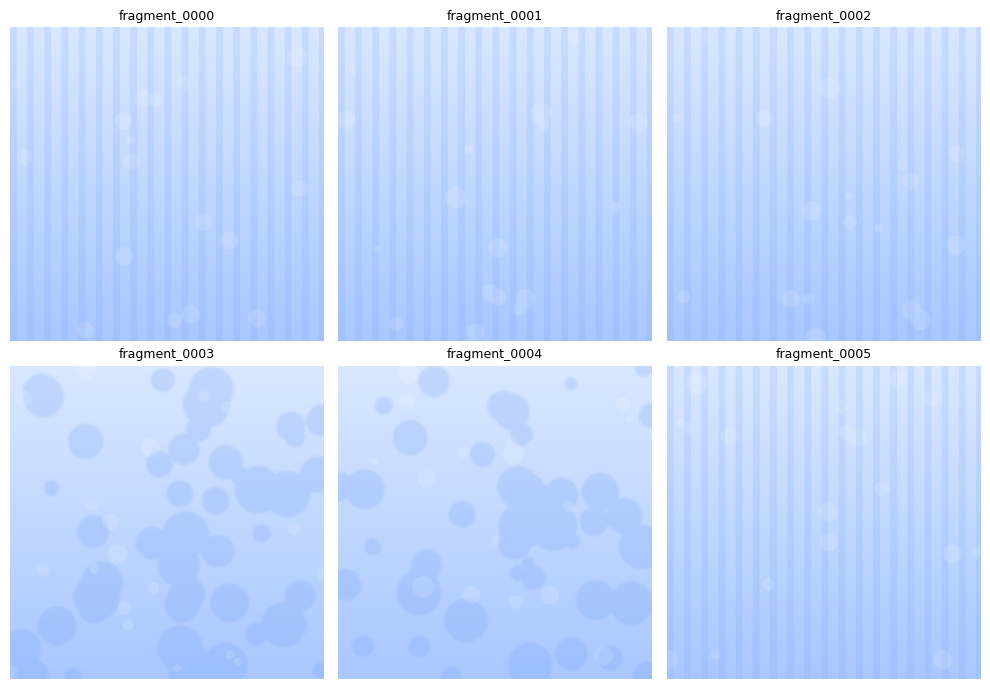

In [7]:
import matplotlib.pyplot as plt

sample_paths = texture_df["texture_path"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()

for ax, path in zip(axes, sample_paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(Path(path).stem, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
TEXTURE_MAP_CSV = PROJECT_DIR / "data" / "processed" / "parameters" / "texture_mapping.csv"
texture_df.to_csv(TEXTURE_MAP_CSV, index=False, encoding="utf-8-sig")
print("Saved:", TEXTURE_MAP_CSV)

Saved: D:\Work\Workspace\Projects\Python\data-driven-surface\data\processed\parameters\texture_mapping.csv
